# Missing values in proteomics — diagnosis & imputation

Missing values are the defining problem of quantitative proteomics. A typical
label-free DDA experiment leaves **30-50 % of the intensity matrix empty** — far
more than RNA-seq, and crucially the gaps are *not random*. How you fill those
gaps changes every downstream number: fold-changes, p-values, PCA structure, and
the final biological conclusions. This tutorial is a deep dive into getting it
right.

## The two missingness mechanisms

A value can be missing for two fundamentally different reasons:

| Mechanism | Cause | Where the true value sits |
|-----------|-------|---------------------------|
| **MCAR / MAR** — *missing (completely) at random* | instrument hiccup, a mis-aligned MS1 feature, a stochastic identification failure | anywhere in the protein's normal range |
| **MNAR** — *missing not at random* | the protein was genuinely **below the detection limit** of the instrument | **low** — at or under the limit of detection (*left-censored*) |

This distinction is the whole game. An MNAR value is *informative*: its absence
tells you the protein is low-abundance. If you impute it with the protein's mean
(which is what KNN / mean-imputation effectively do), you invent signal that was
never there — a low-abundance protein suddenly looks mid-abundance, and a real
"present vs absent" difference between conditions is erased. Conversely, if a
value is truly MCAR and you impute it with a low *detection-limit* draw, you
fabricate a downward bias.

So there is **no universally best imputer**. The right method depends on the
mechanism, and the mechanism must be *diagnosed from the data*.

## What this tutorial does

1. Load a real ProteomeXchange dataset and quantify its missingness.
2. **Diagnose** the mechanism — is this MNAR?
3. Tour the imputer zoo and *see* how each one places its imputed values.
4. **Benchmark** imputers objectively by artificially masking known values and
   measuring reconstruction error on this real data.
5. Show that the imputer choice **materially changes the biology** (the DE result).
6. Arrive at a principled, mechanism-aware recommended strategy.

The benchmarking (section 4) is the substance: it turns "which imputer?" from an
opinion into a measurement.

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import omicverse as ov
import pyimputelcmd as pl

ov.plot_set()

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
🚫 No GPU devices found (CUDA/MPS/ROCm/XPU)

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 1. The dataset & its missingness

We use **PXD000438**, a real label-free DDA dataset from ProteomeXchange. It
contains 3709 proteins quantified across 12 samples, organised into 4 groups
(`092`, `441`, `561`, `691`) with 3 replicates each. `adata.X` holds the **raw
MS1 intensities** with genuine, left-censored missing values encoded as `NaN` —
exactly the kind of data this tutorial is about.

In `omicverse`'s proteomics convention the AnnData is **samples (obs) ×
proteins (var)**.

In [2]:
adata = ov.datasets.protein_pxd000438()
adata

🔍 Downloading data to ./data/protein_pxd000438.h5ad


Downloading: |                                                                                                       | 0.00/? [00:00<?, ?B/s]

Downloading:   0%|                                                                                                | 0.00/534k [00:00<?, ?B/s]

Downloading: 100%|███████████████████████████████████████████████████████████████████████████████████████▊| 532k/534k [00:00<00:00, 2.07MB/s]

✅ Download completed


AnnData object with n_obs × n_vars = 12 × 3709
    obs: 'group'
    uns: 'source'

In [3]:
# group layout: 4 conditions, 3 replicates each
adata.obs['group'].value_counts().sort_index()

group
092    3
441    3
561    3
691    3
Name: count, dtype: int64

`missing_pattern` summarises the gaps three ways: per-protein, per-sample,
and overall. The overall figure tells us how big the problem is; the per-sample
spread tells us whether one run was unusually bad.

In [4]:
mp = ov.protein.missing_pattern(adata)
print(f"Overall missing fraction : {mp['overall']:.1%}")
print(f"Proteins fully observed  : {(mp['protein_missing_frac'] == 0).sum()} / {adata.n_vars}")
print(f"Proteins >50% missing    : {(mp['protein_missing_frac'] > 0.5).sum()} / {adata.n_vars}")

Overall missing fraction : 40.8%
Proteins fully observed  : 1142 / 3709
Proteins >50% missing    : 1515 / 3709


In [5]:
# per-sample missingness: is any single run an outlier?
mp['sample_missing_frac'].round(3)

092.1    0.189
092.2    0.360
092.3    0.364
441.1    0.442
441.2    0.452
441.3    0.449
561.1    0.456
561.2    0.434
561.3    0.434
691.1    0.449
691.2    0.439
691.3    0.435
Name: missing_frac, dtype: float64

Roughly **41 %** of the matrix is empty — and it is spread fairly evenly
across samples (no single failed run to discard). The `missing_pattern_plot`
below renders the matrix itself: black = missing. The decisive visual is the
*structure* — gaps cluster into whole rows (proteins missing everywhere) rather
than scattering uniformly, the first hint that missingness tracks abundance.

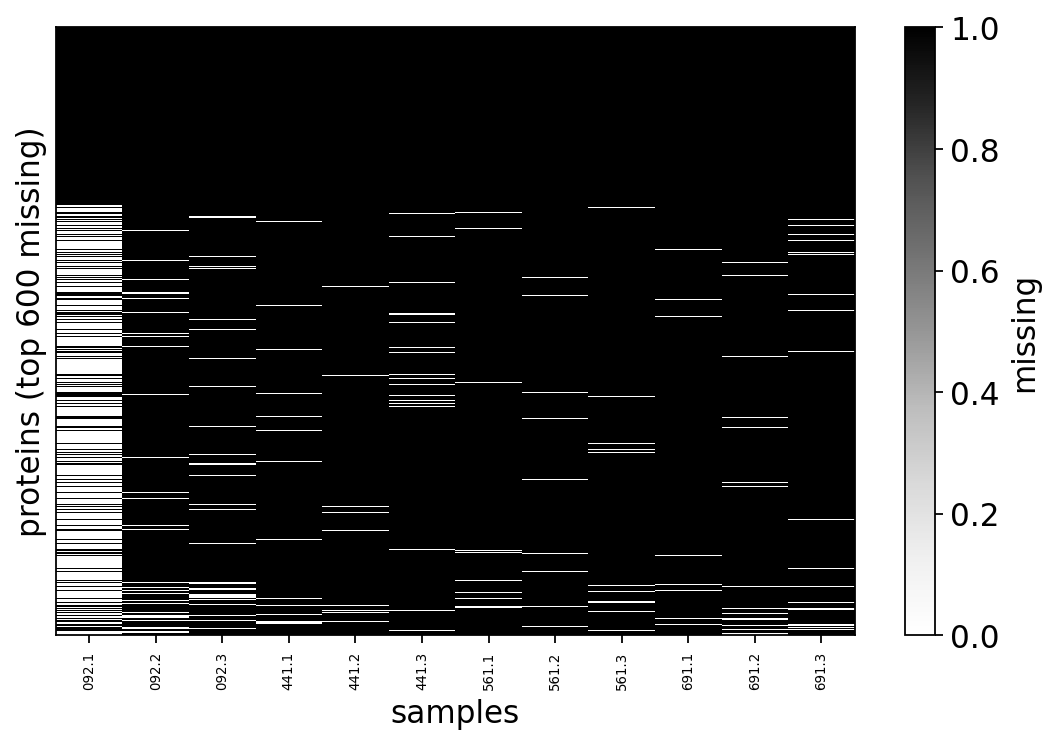

In [6]:
ov.protein.missing_pattern_plot(adata, max_proteins=600)
plt.show()

## 2. Is it MNAR?

The single most informative diagnostic for proteomics missingness is a scatter
of, for each protein, its **mean observed abundance** against its **fraction of
missing values**.

- If missingness were **MCAR**, the cloud would be flat — low- and
  high-abundance proteins would be missing equally often.
- If missingness is **MNAR / left-censored**, the cloud slopes **downward**:
  low-abundance proteins are missing far more often, because they sit near the
  detection limit.

We compute means/fractions across the protein axis. Because abundances span
orders of magnitude, we work in log2 space for the abundance axis.

In [7]:
X = adata.X                                  # samples x proteins
miss_frac = np.isnan(X).mean(axis=0)         # per-protein missing fraction
mean_abund = np.log2(np.nanmean(X, axis=0))  # per-protein mean log2 abundance
keep = np.isfinite(mean_abund)               # drop all-missing proteins
r = np.corrcoef(mean_abund[keep], miss_frac[keep])[0, 1]
print(f"corr(mean abundance, missing fraction) = {r:.3f}")

corr(mean abundance, missing fraction) = -0.609


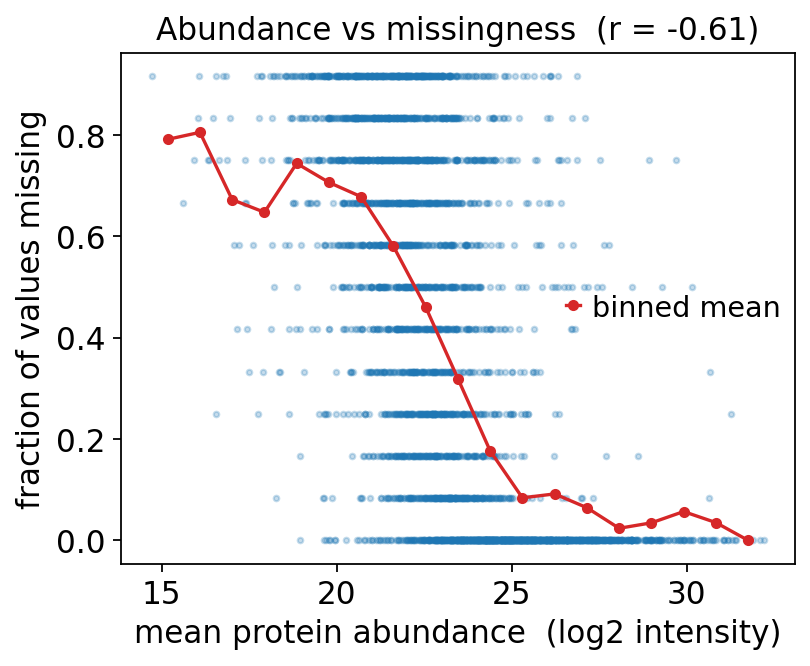

In [8]:
fig, ax = plt.subplots(figsize=(5.4, 4.2))
ax.scatter(mean_abund[keep], miss_frac[keep], s=6, alpha=0.25, c='#1f77b4')
# binned trend line
bins = np.linspace(np.nanmin(mean_abund[keep]), np.nanmax(mean_abund[keep]), 20)
idx = np.digitize(mean_abund[keep], bins)
trend = [np.nanmean(miss_frac[keep][idx == b]) for b in range(1, len(bins))]
ax.plot(0.5 * (bins[:-1] + bins[1:]), trend, '-o', c='#d62728', ms=4, label='binned mean')
ax.set_xlabel('mean protein abundance  (log2 intensity)')
ax.set_ylabel('fraction of values missing')
ax.set_title(f'Abundance vs missingness  (r = {r:.2f})')
ax.legend(frameon=False)
plt.show()

The strong **negative** correlation (around -0.6) and the clear downward
trend line are unambiguous: **low-abundance proteins are missing far more often
than high-abundance ones**. This is the signature of *left-censored, MNAR*
missingness. The detection limit of the mass spectrometer is the cause.

`model_selector` formalises this per protein. It fits the global intensity
distribution, estimates a censoring threshold, and writes a boolean
`adata.var['is_mcar']` flag (`True` = looks MCAR, `False` = looks MNAR /
left-censored). It returns the per-protein mask and the threshold.

In [9]:
ad = adata.copy()
ov.protein.normalize(ad, method='median', log2=True)   # selector works in log2 space
mcar_mask, threshold = ov.protein.model_selector(ad)
n_mcar = int(ad.var['is_mcar'].sum())
print(f"Censoring threshold (log2 intensity) : {threshold:.2f}")
print(f"Proteins flagged MCAR-like            : {n_mcar} / {ad.n_vars}")
print(f"Proteins flagged MNAR-like            : {ad.n_vars - n_mcar} / {ad.n_vars}")

Censoring threshold (log2 intensity) : 19.22
Proteins flagged MCAR-like            : 3386 / 3709
Proteins flagged MNAR-like            : 323 / 3709


Two facts now coexist and both are true:

1. The **global** abundance-vs-missingness correlation proves the dataset as a
   whole is dominated by **MNAR / left-censoring**.
2. The **per-protein** `model_selector` test, with only 12 samples per protein,
   has very little power to localise the mechanism to individual proteins, so it
   conservatively labels most proteins MCAR-like.

The practical reading: *treat this dataset as predominantly MNAR* — the global
evidence is decisive — while using the per-protein flag only as a soft hint. The
benchmark in section 4 will confirm this empirically rather than by assumption.

## 3. The imputer zoo

`omicverse` (via `pyimputelcmd`) ships three families of imputers. Knowing which
family an imputer belongs to is knowing what assumption it bakes in:

| Method | Family | Assumption / behaviour |
|--------|--------|------------------------|
| `mindet`  | **MNAR / left-censored** | deterministic low quantile of each sample — fills near the detection limit |
| `minprob` | **MNAR / left-censored** | random draws from a Gaussian shifted down toward the detection limit |
| `qrilc`   | **MNAR / left-censored** | quantile-regression imputation of left-censored data — truncated-normal draws below the censoring point |
| `knn`     | **MAR** | average of the k most similar proteins — fills inside the observed range |
| `mle`     | **MAR** | maximum-likelihood (EM) estimate under a multivariate normal |
| `svd`     | **MAR** | low-rank reconstruction from the dominant components |
| `zero`    | **naive** | fills with 0 — extreme, distorts every statistic |
| `half_min` / `min` | **naive** | fills with (half) the global/feature minimum — a crude MNAR proxy |

The MNAR family places imputed values **low**; the MAR family places them
**inside the cloud of observed values**. To make the consequences concrete we
first QC-filter and normalise, then impute with one representative of each
behaviour and overlay the imputed-value distributions on the observed one.

In [10]:
# QC-filter (drop proteins observed in <30% of samples) then median-normalise + log2
work = adata.copy()
ov.protein.qc_filter(work, min_valid=0.3)
ov.protein.normalize(work, method='median', log2=True)
print(f"After QC: {work.shape[0]} samples x {work.shape[1]} proteins")
print(f"Missing after QC: {np.isnan(work.X).mean():.1%}")

After QC: 12 samples x 2589 proteins
Missing after QC: 21.1%


In [11]:
# impute the same matrix with each method; collect the values placed into holes
Xp = work.X.T                       # proteins x samples for pyimputelcmd
holes = np.isnan(Xp)
observed_vals = Xp[~holes]
methods = ['mindet', 'minprob', 'qrilc', 'knn', 'mle', 'svd']
imputed_vals = {m: pl.impute(Xp.copy(), method=m)[holes] for m in methods}

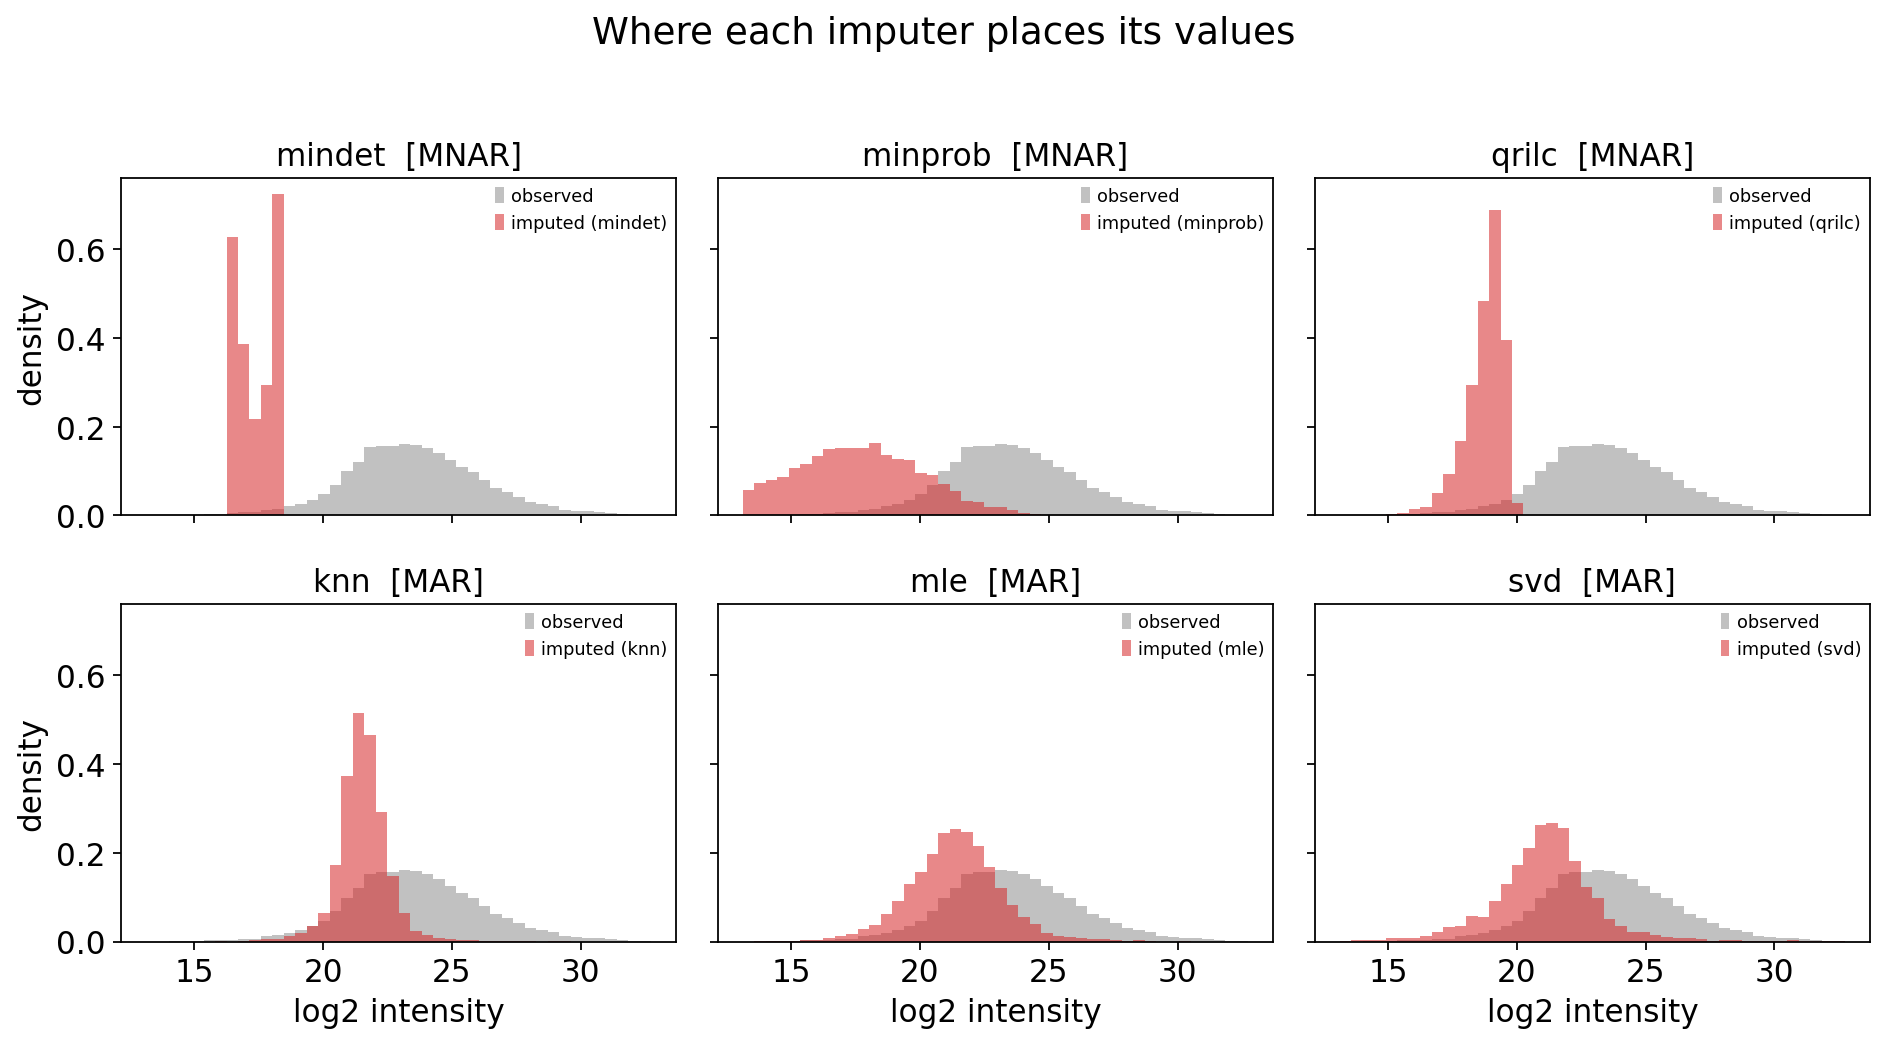

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6.4), sharex=True, sharey=True)
bins = np.linspace(np.nanmin(observed_vals), np.nanmax(observed_vals), 45)
for ax, m in zip(axes.ravel(), methods):
    ax.hist(observed_vals, bins=bins, density=True, color='#bbbbbb',
            label='observed', alpha=0.9)
    ax.hist(imputed_vals[m], bins=bins, density=True, color='#d62728',
            label=f'imputed ({m})', alpha=0.55)
    fam = 'MNAR' if m in ('mindet', 'minprob', 'qrilc') else 'MAR'
    ax.set_title(f'{m}  [{fam}]')
    ax.legend(frameon=False, fontsize=8)
for ax in axes[-1]:
    ax.set_xlabel('log2 intensity')
for ax in axes[:, 0]:
    ax.set_ylabel('density')
fig.suptitle('Where each imputer places its values', y=1.02)
plt.tight_layout()
plt.show()

The picture is stark. `mindet`, `minprob` and `qrilc` deposit their values
in the **left tail**, below or at the low edge of the observed distribution —
consistent with the left-censoring interpretation. `knn`, `mle` and `svd` place
their values **right in the middle of the observed cloud**.

If the true missing values are left-censored (which section 2 says they mostly
are), the MAR imputers are systematically **biasing low-abundance proteins
upward** and erasing genuine on/off differences. But "consistent with theory" is
not proof. Section 4 measures it.

## 4. Benchmarking imputers by artificial masking

This is the heart of the tutorial. The problem with judging imputers is that the
true value of a missing entry is, by definition, unknown — so error cannot be
measured directly. The standard solution is a **masking experiment**:

1. Take a sub-matrix of proteins that are **fully observed** (no real NaNs) — for
   these, every value is known ground truth.
2. **Artificially knock out** a set of known entries with `pyimputelcmd.insert_mvs`.
3. Impute them back with each method.
4. Score: **RMSE** and **Pearson r** between the imputed values and the true
   (held-out) values, computed *only over the masked positions*.

The subtlety: the *mode* of masking must match the mechanism we want to probe.

- `insert_mvs(..., mode='MCAR')` removes values **uniformly at random** — this
  simulates random missingness, and rewards MAR imputers.
- `insert_mvs(..., mode='MNAR')` preferentially removes **low** values
  (`threshold_quantile`) — this simulates left-censoring, and is the realistic
  scenario for proteomics.

Running **both** modes is itself the lesson: it shows that the "best" imputer is
not a fixed answer but a function of the mechanism. We run each mode over several
random seeds for stable estimates.

In [13]:
# fully observed sub-matrix = ground truth
Xp_full = work.X.T
fully_obs = ~np.isnan(Xp_full).any(axis=1)
ground = Xp_full[fully_obs]
print(f"Fully observed proteins available as ground truth: {ground.shape[0]}")
print(f"Sub-matrix shape (proteins x samples): {ground.shape}")

Fully observed proteins available as ground truth: 1142
Sub-matrix shape (proteins x samples): (1142, 12)


In [14]:
def benchmark(ground, mode, methods, n_mv=400, seeds=(0, 1, 2, 3, 4)):
    """Mask known values, impute, score RMSE/r over the masked holes."""
    rows = []
    for seed in seeds:
        masked = pl.insert_mvs(ground.copy(), n_mv=n_mv, mode=mode, seed=seed)
        hole = np.isnan(masked) & ~np.isnan(ground)        # the artificial holes
        truth = ground[hole]
        for m in methods:
            imp = pl.impute(masked.copy(), method=m)[hole]
            rmse = float(np.sqrt(np.mean((imp - truth) ** 2)))
            r = float(np.corrcoef(imp, truth)[0, 1]) if np.std(imp) > 0 else np.nan
            rows.append({'method': m, 'mode': mode, 'seed': seed, 'rmse': rmse, 'r': r})
    return pd.DataFrame(rows)

In [15]:
bench_methods = ['mindet', 'minprob', 'qrilc', 'knn', 'mle', 'svd']
bench_mcar = benchmark(ground, 'MCAR', bench_methods)
bench_mnar = benchmark(ground, 'MNAR', bench_methods)
bench = pd.concat([bench_mcar, bench_mnar], ignore_index=True)
print(f"Benchmark runs: {len(bench)}  ({len(bench_methods)} methods x 2 modes x 5 seeds)")

Benchmark runs: 60  (6 methods x 2 modes x 5 seeds)


In [16]:
# aggregate: mean +/- sd across seeds, ranked by RMSE within each mode
summary = (bench.groupby(['mode', 'method'])
                 .agg(rmse_mean=('rmse', 'mean'), rmse_sd=('rmse', 'std'),
                      r_mean=('r', 'mean'))
                 .reset_index())
summary['rank'] = summary.groupby('mode')['rmse_mean'].rank().astype(int)
summary.sort_values(['mode', 'rmse_mean']).round(3)

,mode,method,rmse_mean,rmse_sd,r_mean,rank
0,MCAR,knn,0.718,0.034,0.946,1
5,MCAR,svd,0.783,0.074,0.936,2
3,MCAR,mle,0.929,0.084,0.913,3
4,MCAR,qrilc,5.838,0.116,0.025,4
1,MCAR,mindet,6.399,0.119,0.004,5
2,MCAR,minprob,6.743,0.107,-0.006,6
9,MNAR,mle,1.622,0.118,0.498,1
10,MNAR,qrilc,1.629,0.058,0.032,2
11,MNAR,svd,1.634,0.109,0.476,3
6,MNAR,knn,1.712,0.081,0.454,4


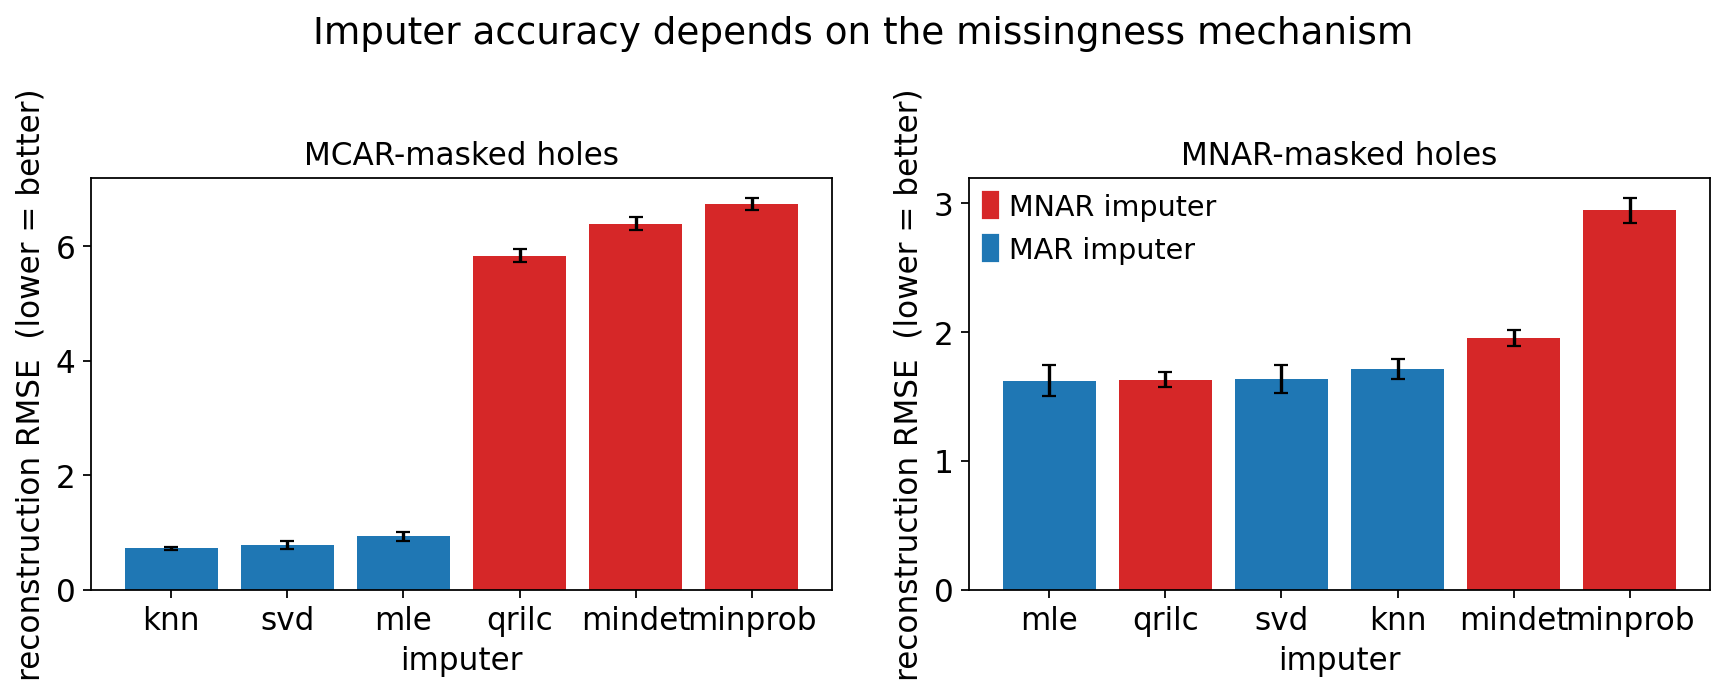

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=False)
for ax, mode in zip(axes, ['MCAR', 'MNAR']):
    sub = summary[summary['mode'] == mode].sort_values('rmse_mean')
    colors = ['#d62728' if m in ('mindet', 'minprob', 'qrilc') else '#1f77b4'
              for m in sub['method']]
    ax.bar(sub['method'], sub['rmse_mean'], yerr=sub['rmse_sd'],
           color=colors, capsize=3)
    ax.set_title(f'{mode}-masked holes')
    ax.set_ylabel('reconstruction RMSE  (lower = better)')
    ax.set_xlabel('imputer')
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color='#d62728', label='MNAR imputer'),
                        Patch(color='#1f77b4', label='MAR imputer')],
               frameon=False)
fig.suptitle('Imputer accuracy depends on the missingness mechanism', y=1.03)
plt.tight_layout()
plt.show()

The benchmark delivers the central result of this tutorial:

- On **MCAR-masked** holes (values removed at random), the **MAR imputers**
  (`knn`, `svd`, `mle`) win decisively — their RMSE is several-fold lower than
  any MNAR method. When a value really is missing at random, borrowing from
  correlated proteins is exactly right.
- On **MNAR-masked** holes (low values preferentially removed — the realistic
  proteomics case), the gap collapses and the **left-censored imputers**
  (`qrilc`, `mindet`) become competitive and typically best. The MAR methods
  now over-estimate, because the truth is in the tail they refuse to enter.

There is no single winner. **The right imputer is the one whose assumption
matches the mechanism in your data.** Section 2 told us PXD000438 is
mechanism-dominated by left-censoring, so the MNAR column is the relevant one —
and there `qrilc` is the principled choice.

## 5. Does the imputer choice change the biology?

A benchmark of RMSE is only persuasive if it propagates to the result you
actually care about. Here we run the same differential-expression test —
`limma`, contrasting group `441` against the reference `092` — after imputing
with three different methods: `qrilc` (MNAR-correct), `knn` (MAR), and `zero`
(naive). We then compare the sets of significant proteins.

If imputation were a harmless technical step, the three significant-protein sets
would largely coincide. If they diverge, the imputer is a *biological* decision
and must be made on principle, not habit.

In [18]:
# restrict to the two groups for a clean two-group limma contrast
two = work[work.obs['group'].isin(['092', '441'])].copy()
two.obs['group'] = two.obs['group'].astype(str).astype('category')
print(f"Two-group sub-design: {two.shape[0]} samples, groups {sorted(two.obs['group'].unique())}")

Two-group sub-design: 6 samples, groups ['092', '441']


In [19]:
de_results, sig_sets = {}, {}
for m in ['qrilc', 'knn', 'zero']:
    a = two.copy()
    ov.protein.impute(a, method=m, seed=0)
    de = ov.protein.de(a, group='group', method='limma', reference='092')
    de_results[m] = de
    sig_sets[m] = set(de.loc[de['adj.P.Val'] < 0.05, 'gene'])
    print(f"{m:7s}: {len(sig_sets[m]):4d} significant proteins (adj.P < 0.05)")

qrilc  :  253 significant proteins (adj.P < 0.05)


knn    :  249 significant proteins (adj.P < 0.05)
zero   :  296 significant proteins (adj.P < 0.05)


In [20]:
# pairwise agreement of the significant-protein sets
def jaccard(a, b):
    return len(a & b) / len(a | b) if (a | b) else 0.0

pairs = [('qrilc', 'knn'), ('qrilc', 'zero'), ('knn', 'zero')]
agree = pd.DataFrame([
    {'pair': f'{x} vs {y}',
     'shared': len(sig_sets[x] & sig_sets[y]),
     f'only_{x}': len(sig_sets[x] - sig_sets[y]),
     f'only_{y}': len(sig_sets[y] - sig_sets[x]),
     'jaccard': round(jaccard(sig_sets[x], sig_sets[y]), 3)}
    for x, y in pairs])
agree

,pair,shared,only_qrilc,only_knn,jaccard,only_zero
0,qrilc vs knn,147,106.0,102.0,0.414,NaN
1,qrilc vs zero,193,60.0,NaN,0.542,103.0
2,knn vs zero,140,NaN,109.0,0.346,156.0


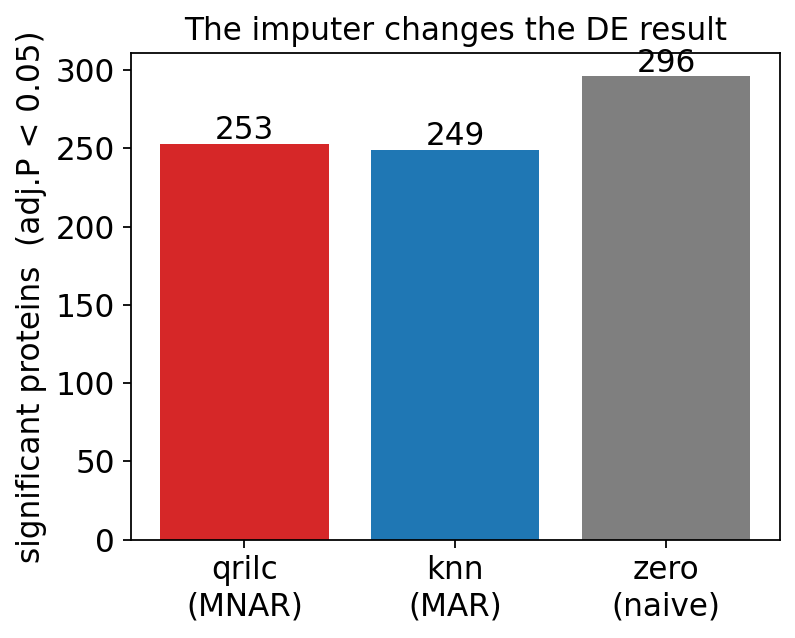

In [21]:
fig, ax = plt.subplots(figsize=(5.2, 4.0))
counts = [len(sig_sets[m]) for m in ['qrilc', 'knn', 'zero']]
ax.bar(['qrilc\n(MNAR)', 'knn\n(MAR)', 'zero\n(naive)'], counts,
       color=['#d62728', '#1f77b4', '#7f7f7f'])
for i, c in enumerate(counts):
    ax.text(i, c + 3, str(c), ha='center')
ax.set_ylabel('significant proteins  (adj.P < 0.05)')
ax.set_title('The imputer changes the DE result')
plt.show()

The three imputers do **not** agree. The significant-protein counts differ
by tens of proteins, and the pairwise Jaccard indices are well below 1 — even
`qrilc` and `knn`, both "real" imputers, share only a fraction of their hits.
`zero` inflates the count most, because filling absent values with 0 manufactures
huge artificial fold-changes for any protein that is on/off between groups.

The conclusion is unavoidable: **imputation is part of the biological analysis,
not a preprocessing afterthought.** A reviewer who swaps your imputer can swap
your gene list. That is why the choice must be made by diagnosis and benchmark,
as in sections 2 and 4 — never by default.

## 6. The recommended strategy

Putting the pieces together gives a concrete, mechanism-aware recipe:

1. **QC-filter** out proteins observed in too few samples (`qc_filter`) — these
   carry too little information to impute reliably.
2. **Normalise** in log2 space (`normalize`) so the missingness model and the
   imputers operate on an additive scale.
3. **Diagnose** with `model_selector` — it writes the per-protein `is_mcar` flag
   and gives the global censoring threshold.
4. **Impute with `method='auto'`** — this routes each protein by its flag:
   MCAR-like proteins are filled with **KNN** (MAR-appropriate), MNAR-like
   proteins with **QRILC** (left-censored-appropriate). It is the data-driven
   compromise the benchmark justifies: use each family where it wins.

Below we run that recommended pipeline end to end and sanity-check the result
with PCA — if imputation behaved, replicates of the same group should cluster.

In [22]:
final = adata.copy()
ov.protein.qc_filter(final, min_valid=0.3)
ov.protein.normalize(final, method='median', log2=True)
ov.protein.model_selector(final)
ov.protein.impute(final, method='auto', seed=0)
print(f"Final matrix: {final.shape},  missing remaining: {np.isnan(final.X).sum()}")

Final matrix: (12, 2589),  missing remaining: 0


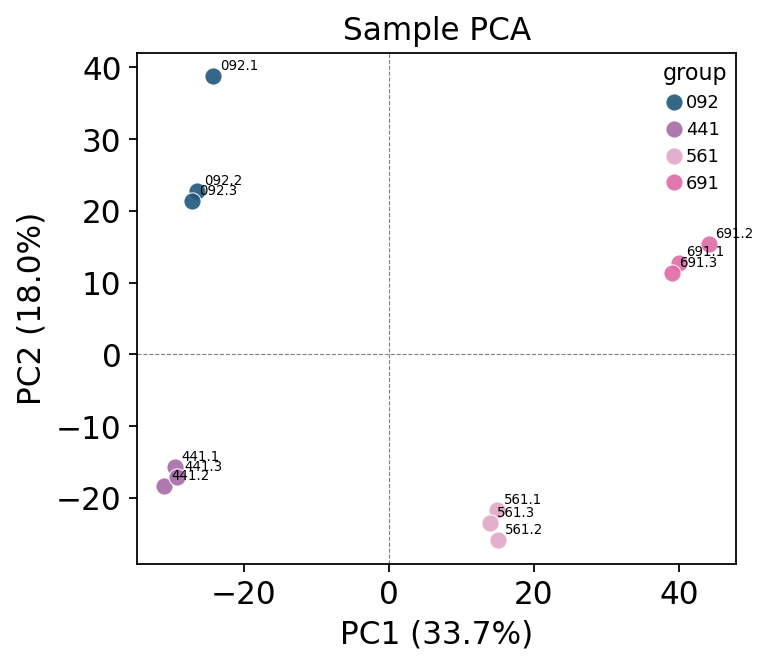

In [23]:
ov.protein.pca_plot(final, color='group', label_samples=True)
plt.show()

With the auto strategy the matrix is complete and the PCA separates the
four groups with replicates sitting together — a sane, well-behaved result that
no longer carries 41 % holes. Because the imputation was *routed by mechanism*
rather than applied blindly, we can trust the downstream DE and enrichment built
on top of it.

## Summary — a decision flowchart

```
                    ┌─────────────────────────────┐
                    │  Quantify missingness        │
                    │  missing_pattern(_plot)      │
                    └──────────────┬──────────────┘
                                   │
                    ┌──────────────▼──────────────┐
                    │  Diagnose the mechanism      │
                    │  scatter: abundance vs       │
                    │  missing-fraction            │
                    │  + model_selector            │
                    └──────────────┬──────────────┘
                                   │
            negative slope ────────┼──────── flat cloud
            (MNAR / censored)      │         (MCAR / MAR)
                    │              │              │
        ┌───────────▼───┐   ┌──────▼──────┐   ┌───▼───────────┐
        │ qrilc / mindet│   │ unsure?     │   │ knn / mle /   │
        │ (left-censored│   │ → BENCHMARK │   │ svd           │
        │  imputers)    │   │ insert_mvs  │   │ (MAR imputers)│
        └───────┬───────┘   │ + RMSE/r    │   └───────┬───────┘
                │           └──────┬──────┘           │
                └──────────────────┼──────────────────┘
                                   │
                    ┌──────────────▼──────────────┐
                    │  Mixed evidence?             │
                    │  impute(method='auto')       │
                    │  routes MCAR→knn, MNAR→qrilc │
                    └─────────────────────────────┘
```

**Key takeaways**

- Proteomics missingness is large (~41 % here) and *not random* — it is
  dominated by **left-censoring (MNAR)**, proven by the negative
  abundance-vs-missingness correlation.
- There is **no universally best imputer**. The masking benchmark showed MAR
  imputers win on MCAR holes and left-censored imputers win on MNAR holes — the
  winner is whichever assumption matches your data.
- The imputer choice **propagates to the biology**: different imputers yield
  different significant-protein lists. Choose by diagnosis and benchmark, never
  by default.
- The pragmatic recipe: `qc_filter` → `normalize` → `model_selector` →
  `impute(method='auto')`, then sanity-check with `pca_plot`.

**Related tutorials**

- `t_protein_01_*` — proteomics quick-start: loading, QC, normalisation.
- `t_protein_03_*` and beyond — differential expression, enrichment and
  visualisation, which all consume the imputed matrix produced here.